In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import scanpy as sc
import seaborn as sns
import pandas as pd

In [3]:
import sys
sys.path.append('/Users/koush/Projects/SpaceOracle/src')
sys.path.append('/Users/koush/Projects/SpaceOracle')
from SpaceTravLR.models.parallel_estimators import SpatialCellularProgramsEstimator

In [4]:
ref_adata = sc.read_h5ad('/Volumes/SSD/training_data/mouse_kidney_13.h5ad')
test_adata = sc.read_h5ad('/Volumes/SSD/training_data/mouse_kidney_14.h5ad')

ref_adata, test_adata

(AnnData object with n_obs × n_vars = 8509 × 3058
     obs: 'ct1', 'ct2', 'ct3', 'ct4', 'cond', 'medulla_cortex', 'domain', 'cell_type', 'cell_type_int'
     uns: 'cell_thresholds', 'cell_type_colors', 'neighbors', 'pca', 'received_ligands', 'received_ligands_tfl', 'umap'
     obsm: 'X_pca', 'X_umap', 'spatial', 'spatial_unscaled'
     varm: 'PCs'
     layers: 'imputed_count', 'normalized_count', 'raw_count'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 6102 × 3058
     obs: 'batch', 'rxn', 'n_counts', 'ct1', 'ct2', 'ct3', 'high_q', 'ct4', 'chip', 'exp', 'cond', 'samp-id', 'samp-type', 'cell_type', 'cell_type_int', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
     var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', '

In [18]:
ref_adata = ref_adata[ref_adata.obs['cell_type'] != 'Mesenchymal_Stromal']

from SpaceTravLR.tools.network import encode_labels

ref_adata.obs['cell_type_int'] = ref_adata.obs['cell_type'].apply(
    lambda x: encode_labels(ref_adata.obs['cell_type'], reverse_dict=True)[x])

In [19]:
test_adata.obs[['cell_type_int']] = test_adata.obs[['cell_type']].replace(dict(
    zip(
        ref_adata.obs['cell_type'],
        ref_adata.obs['cell_type_int']
    )
))

In [20]:
ref_adata.obs[['cell_type', 'cell_type_int']].drop_duplicates()

,cell_type,cell_type_int
AAACCCAAGAGGGTCT-13,Myeloid,3
AAACCCAAGCGTGTTT-13,NK,4
AAACCCAAGTCTAACC-13,T,5
AAACCCAAGTGCCCGT-13,B,0
AAACCCATCCCTCGTA-13,Endothelial,1
AAACGAACACATTCGA-13,Epithelial,2


In [21]:
test_adata.obs[['cell_type', 'cell_type_int']].drop_duplicates()

,cell_type,cell_type_int
AAACCCAAGCCATTCA-1,Myeloid,3
AAACCCACAAATCAGA-1,Epithelial,2
AAACCCATCTGCGATA-1,Endothelial,1
AAACGAACATACTTTC-1,T,5
AACGTCAAGAATGTTG-1,B,0
AAGTTCGCAGGGTCTC-1,NK,4


In [22]:
from SpaceTravLR.tools.network import RegulatoryFactory
import numpy as np
import torch

co_grn = RegulatoryFactory(
    colinks_path='/Volumes/SSD/training_data/mouse_kidney_13_colinks.pkl',
    annot='cell_type_int'
)

In [23]:
del ref_adata.uns

In [149]:
idx = np.random.rand(ref_adata.n_obs) < 0.5

adata1 = ref_adata[idx].copy()
adata2 = ref_adata[~idx].copy()

In [154]:
del adata1.uns
del adata2.uns

In [182]:
def rotate_adata(adata, angle_degrees, key="spatial", new_key="spatial_rotated"):
    # Convert to radians
    theta = np.deg2rad(angle_degrees)
    
    # Rotation matrix
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])
    
    coords = adata.obsm[key]
    
    # Center before rotation (optional but usually desired)
    center = coords.mean(axis=0)
    coords_centered = coords - center
    
    rotated = coords_centered @ R.T + center
    
    adata.obsm[new_key] = rotated
    return adata

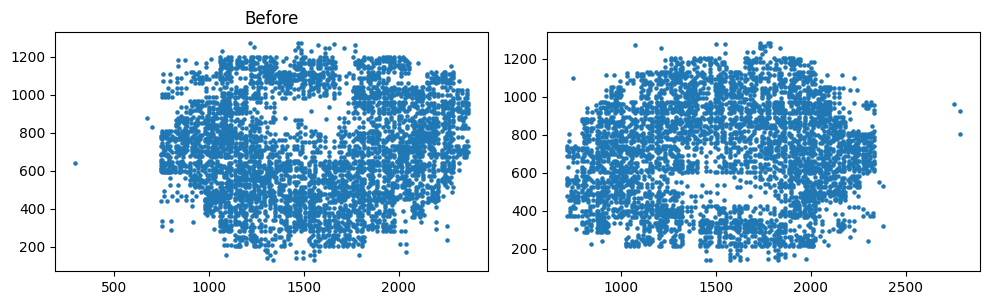

In [218]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Before
axes[0].scatter(
    adata1.obsm["spatial"][:, 0],
    adata1.obsm["spatial"][:, 1],
    s=5
)
axes[0].set_title("Before")
axes[0].set_aspect("equal")

adata3 = rotate_adata(adata2, angle_degrees=180)

axes[1].scatter(
    adata3.obsm["spatial_rotated"][:, 0],
    adata3.obsm["spatial_rotated"][:, 1],
    s=5
)
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

In [256]:
adata2.obsm['spatial'] = adata3.obsm['spatial_rotated']

In [230]:
estimator = SpatialCellularProgramsEstimator(
    adata1, 
    target_gene='Mif', 
    cluster_annot='cell_type_int',
    radius=400, 
    spatial_dim=32,
    contact_distance=50,
    grn=co_grn,
)

In [367]:
estimator.fit(
    num_epochs=50, 
    learning_rate=5e-3, 
    score_threshold=0.2, 
    l1_reg=1e-9, 
    estimator='lasso'
)

Fitting Mif with 459 modulators
	39 Transcription Factors
	321 Ligand-Receptor Pairs
	99 TranscriptionFactor-Ligand Pairs
0: 0.8647 | 0.8866
1: 0.8854 | 0.8901
2: 0.9789 | 0.9889
3: 0.8236 | 0.8239
4: 0.9891 | 0.9990
5: 0.8743 | 0.9183


In [368]:
betadata_ref = estimator.betadata

In [369]:
estimator_test = SpatialCellularProgramsEstimator(
    adata2, 
    target_gene='Mif', 
    cluster_annot='cell_type_int',
    radius=400, 
    spatial_dim=32,
    contact_distance=50,
    grn=co_grn,
)

In [370]:
estimator_test.fit(
    num_epochs=50, 
    learning_rate=5e-3, 
    score_threshold=0.2, 
    l1_reg=1e-9, 
    estimator='lasso'
)

Fitting Mif with 459 modulators
	39 Transcription Factors
	321 Ligand-Receptor Pairs
	99 TranscriptionFactor-Ligand Pairs
0: 0.8358 | 0.8810
1: 0.8909 | 0.8926
2: 0.9742 | 0.9871
3: 0.8055 | 0.8052
4: 0.9944 | 0.9993
5: 0.8924 | 0.9379


In [371]:
betadata = estimator_test.get_betas()

In [372]:
estimator_test.models = estimator.models

In [373]:
betadata_transfer = estimator_test.get_betas()

In [374]:
from sklearn.metrics import r2_score

In [383]:
betadata_ref[[i for i in betadata_ref.columns if '$' not in i]].mean().sort_values(
    key=abs, ascending=False).head(20)

beta_Tfcp2l1      0.399402
beta_Id4         -0.335370
beta_Mbd1         0.311483
beta_Gata3        0.264001
beta0             0.255151
beta_Sp4         -0.235224
beta_Tead1        0.198989
beta_Pax2         0.188567
beta_Klf5        -0.166220
beta_Jdp2        -0.166029
beta_Fosl2       -0.151897
beta_Igf1#Klf6    0.139840
beta_Bhlhe40      0.133970
beta_Id1          0.128878
beta_Sim1         0.112071
beta_Sim2         0.111578
beta_Klf12       -0.108396
beta_Pf4#Creb5    0.100135
beta_Klf8        -0.093910
beta_Hes1        -0.090318
dtype: float32

array([['cortex'],
       ['cortex'],
       ['medulla'],
       ...,
       ['cortex'],
       ['cortex'],
       ['medulla']], dtype=object)

In [ ]:
adata2

In [398]:
adata2.obs[['ct3']]

,ct3
AAACCCAAGCGTGTTT-13,NK_0
AAACCCAAGTGCCCGT-13,B
AAACGAAAGGCTAGCA-13,Mac_2
AAACGAACAACAGCCC-13,Mac_2
AAACGAACACATTCGA-13,Epithelial_TDLH_IM_Juxtamedullary
...,...
TTTGGTTTCATTCGTT-13,Endothelial_Capilary
TTTGGTTTCTCTTGCG-13,Mac_4
TTTGTTGGTAGGATAT-13,Principal_Cells_Npy6r+
TTTGTTGGTTGAGGAC-13,Mac_2


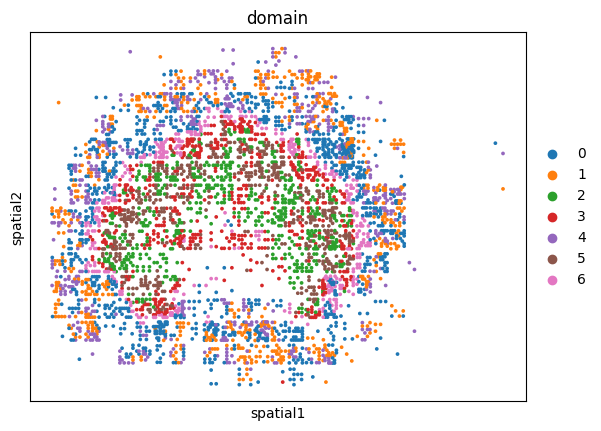

In [402]:
sc.pl.embedding(adata2, 'spatial', color='domain')

In [423]:
pd.DataFrame({
    'Original': betadata.loc[mask].mean(),
    'Transfer': betadata_transfer.loc[mask].mean(),
    'Diff': betadata_transfer.loc[mask].mean() - betadata.loc[mask].mean()
}).replace(0, np.nan).dropna().sort_values(
    by='Diff', ascending=False, key=abs).head(20)

,Original,Transfer,Diff
beta_Ccl6$Ccr2,-0.187115,-0.012172,0.174944
beta_Tead1,0.500401,0.330142,-0.170259
beta_Pax8,0.213092,0.094892,-0.118200
beta_Stat5a,-0.030673,-0.142689,-0.112016
beta_Tfcp2l1,0.551216,0.447630,-0.103586
beta_Pax5,0.075645,-0.021973,-0.097618
beta_Il1b#Jun,0.030005,0.127460,0.097455
beta_Il1b#Id2,-0.089704,0.001666,0.091370
beta_Npas3,-0.052716,0.032455,0.085172
beta_Mbd1,0.300539,0.377751,0.077212


In [ ]:
beta_Pax8, 

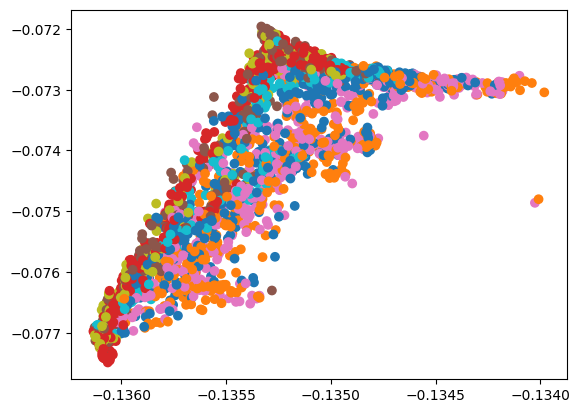

In [427]:
mask = adata2.obs['cell_type'] == 'Myeloid'

plt.scatter(
    betadata.loc[mask, 'beta_Il1b#Junb'].values,
    betadata_transfer.loc[mask, 'beta_Il1b#Junb'].values,
    c=adata2.obs.loc[mask, 'domain'].astype('category').cat.codes,
    cmap='tab10'
)


In [311]:
emb = pd.read_csv('/tmp/df_combined_with_embeddings.csv', index_col=0)

In [315]:
emb[[i for i in emb.columns if 'emb_' in i]].values

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [121]:
df1 = betadata.mean().to_frame()
df1.columns=['beta']
df2 = betadata_transfer.mean().to_frame()
df2.columns=['beta_transfer']


In [144]:
df1.loc['beta_Ebf1'], df2.loc['beta_Ebf1']

(beta    0.001683
 Name: beta_Ebf1, dtype: float32,
 beta_transfer    0.011645
 Name: beta_Ebf1, dtype: float32)

In [101]:
betadata[mask].mean().head(10)

beta0          -0.059917
beta_Atf3      -0.151514
beta_Batf       0.466738
beta_Bhlhe40    0.435031
beta_Creb5      0.201754
beta_Crem       0.278612
beta_E2f3       0.379581
beta_Ebf1      -0.032082
beta_Egr1      -0.015893
beta_Fosb      -0.258142
dtype: float32

In [138]:
ref_adata.to_df()[['Fosb']].mean()

Fosb    0.788689
dtype: float32

In [139]:
test_adata.to_df()[['Fosb']].mean()

Fosb    0.53294
dtype: float32

<Axes: xlabel='x', ylabel='y'>

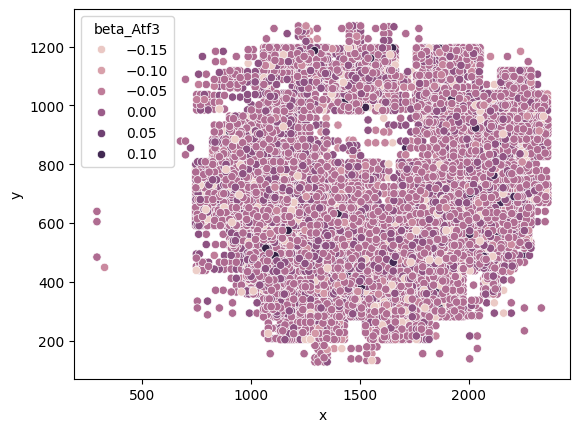

In [54]:
sns.scatterplot(
    data=betadata_ref.join(estimator.xy_df), x='x', y='y', hue='beta_Atf3')